<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-4-Nonholonomic-Mechanics/Untitled165.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Minimizing a Gravitational Potential under Nonholonomic Constraint**

**Problem:**  Given two points $A=(a_0,b_0,c_0)$ and $B=(a_1,b_1,c_1)$ in $\mathbb{R}^3_{xyz}$, with $c_1>c_0$,  choose among all horizontal curves

$$
\gamma:[0,1]\rightarrow \mathbb{R}^3
$$

joining $A$ and $B$ those that minimize the potential which is inversely proportional to the distance from the $z$--axis.

 **Learning the curve and the Lagrange multiplier simultaneously**

In this approach we learn both the curve and the Lagrange multiplier using a neural network.
We consider a network of the form
$$
NN(\theta,t)=\big(x_\theta(t),y_\theta(t),z_\theta(t),\lambda_\theta(t)\big),
$$
where the endpoint conditions are enforced by hard embedding them into the network representation:
\begin{align*}
x_\theta(t) &= 1-2t + t(1-t)\,\mathrm{nn}^1_\theta(t), \\
y_\theta(t) &= t(1-t)\,\mathrm{nn}^2_\theta(t), \\
z_\theta(t) &= 2\pi t + t(1-t)\,\mathrm{nn}^3_\theta(t), \\
\lambda_\theta(t) &= \mathrm{nn}^4_\theta(t).
\end{align*}

Here $\mathrm{nn}^j_\theta$ denote the outputs of a feed-forward neural network with parameters $\theta$.

The loss functional is the discretized action
$$
L(\theta)=
\int_0^1
\left(
\frac{1}{\sqrt{x_\theta^2+y_\theta^2}}
-
\lambda_\theta
\big(\dot z_\theta + 2x_\theta\dot y_\theta - 2y_\theta\dot x_\theta\big)
\right)\,dt.
$$

Epoch 0: Loss=429.28592, Action=3.40225, Constraint=42.58837
Epoch 200: Loss=184.55734, Action=1.14577, Constraint=18.34116
Epoch 400: Loss=33.49057, Action=0.36641, Constraint=3.31242
Epoch 600: Loss=10.20068, Action=0.73014, Constraint=0.94705
Epoch 800: Loss=8.77339, Action=0.78203, Constraint=0.79914
Epoch 1000: Loss=8.13879, Action=0.76062, Constraint=0.73782
Epoch 1200: Loss=7.52750, Action=0.74114, Constraint=0.67864
Epoch 1400: Loss=6.91644, Action=0.72373, Constraint=0.61927
Epoch 1600: Loss=6.30656, Action=0.70707, Constraint=0.55995
Epoch 1800: Loss=5.70291, Action=0.68981, Constraint=0.50131
Epoch 2000: Loss=5.11154, Action=0.67034, Constraint=0.44412
Epoch 2200: Loss=4.53729, Action=0.64701, Constraint=0.38903
Epoch 2400: Loss=3.98355, Action=0.61837, Constraint=0.33652
Epoch 2600: Loss=3.45344, Action=0.58318, Constraint=0.28703
Epoch 2800: Loss=2.95120, Action=0.54022, Constraint=0.24110
Epoch 3000: Loss=2.48278, Action=0.48785, Constraint=0.19949
Epoch 3200: Loss=2.0553

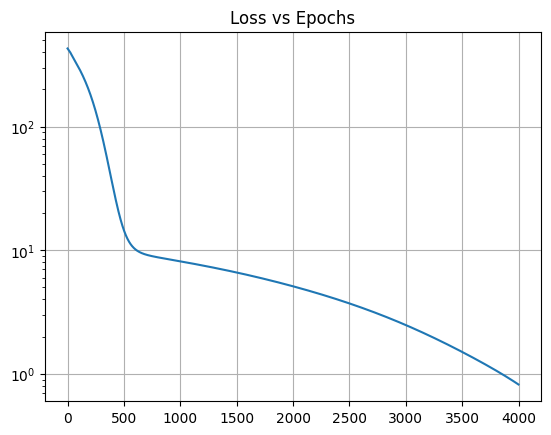

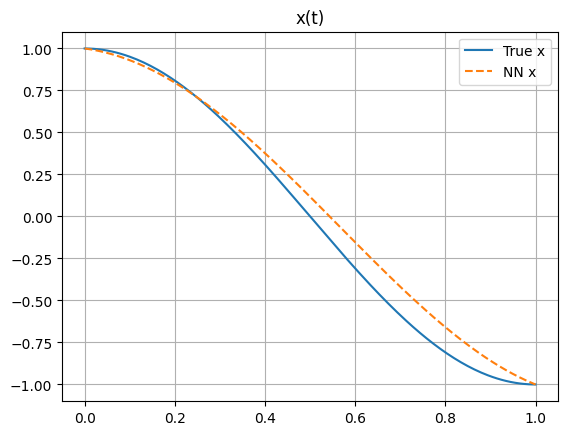

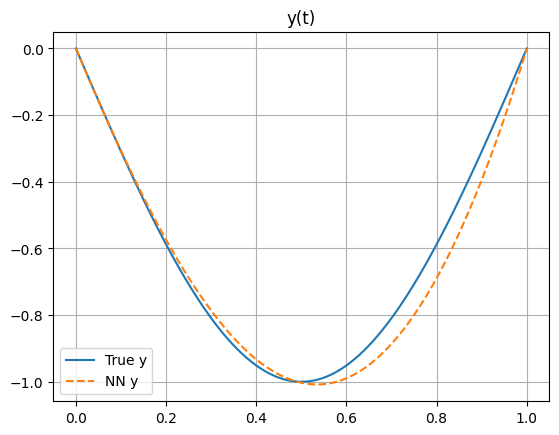

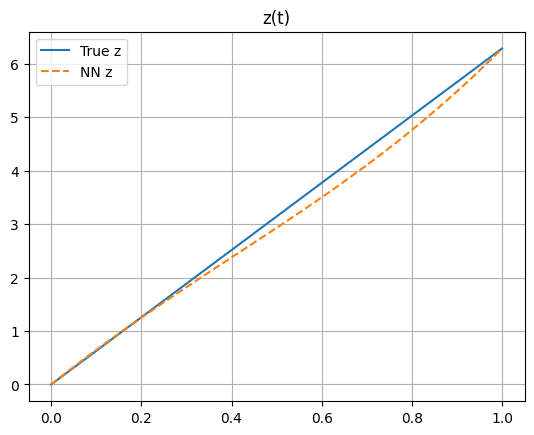

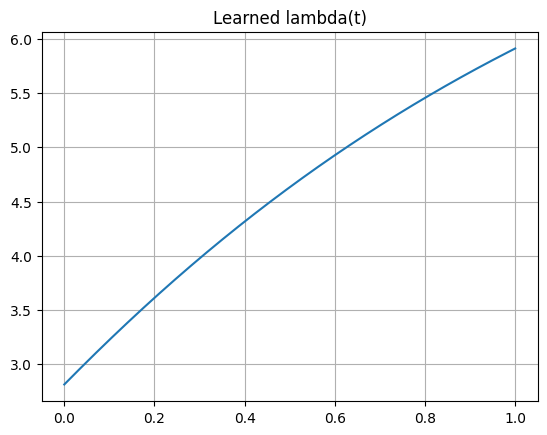

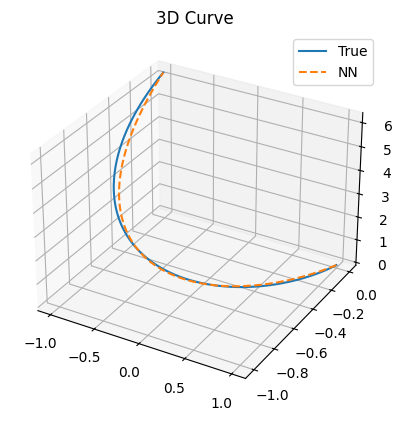

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Model
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(4)  # nn1, nn2, nn3, nn4
    ])

model = build_model()
optimizer = tf.keras.optimizers.Adam(1e-4)

# -----------------------------
# Grid
# -----------------------------
N = 200
t_np = np.linspace(0.0, 1.0, N).reshape(-1,1).astype(np.float32)
t = tf.convert_to_tensor(t_np)

# -----------------------------
# Curve + lambda (hard embedding)
# -----------------------------
def forward(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)

        nn = model(t)
        nn1 = nn[:,0:1]
        nn2 = nn[:,1:2]
        nn3 = nn[:,2:3]
        nn4 = nn[:,3:4]

        x = 1 - 2*t + t*(1-t)*nn1
        y = t*(1-t)*nn2
        z = 2*np.pi*t + t*(1-t)*nn3
        lam = nn4

    dx = tape.gradient(x, t)
    dy = tape.gradient(y, t)
    dz = tape.gradient(z, t)

    return x, y, z, lam, dx, dy, dz

# -----------------------------
# Loss = action
# -----------------------------
def loss_fn():
    x, y, z, lam, dx, dy, dz = forward(t)

    r = tf.sqrt(x**2 + y**2 + 1e-6)

    constraint = dz + 2*x*dy - 2*y*dx

    integrand = 1.0/r - lam * constraint

    loss = tf.reduce_mean(integrand)

    # small stabilization (important)
    constraint_reg = tf.reduce_mean(constraint**2)

    return loss + 10.0 * constraint_reg, loss, constraint_reg

# -----------------------------
# Training
# -----------------------------
epochs = 4000
loss_hist = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        loss, act, cons = loss_fn()

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_hist.append(float(loss.numpy()))

    if ep % 200 == 0:
        print(f"Epoch {ep}: Loss={float(loss.numpy()):.5f}, "
              f"Action={float(act.numpy()):.5f}, "
              f"Constraint={float(cons.numpy()):.5f}")

# -----------------------------
# Extract solution
# -----------------------------
x_pred, y_pred, z_pred, lam_pred, _, _, _ = forward(t)

x_pred = x_pred.numpy().flatten()
y_pred = y_pred.numpy().flatten()
z_pred = z_pred.numpy().flatten()
lam_pred = lam_pred.numpy().flatten()

# -----------------------------
# True solution
# -----------------------------
t_true = t_np.flatten()

x_true = np.cos(np.pi*t_true)
y_true = -np.sin(np.pi*t_true)
z_true = 2*np.pi*t_true

# -----------------------------
# Plots
# -----------------------------

# Loss
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Loss vs Epochs")
plt.grid()
plt.show()

# x
plt.figure()
plt.plot(t_true, x_true, label="True x")
plt.plot(t_true, x_pred, '--', label="NN x")
plt.legend(); plt.title("x(t)"); plt.grid(); plt.show()

# y
plt.figure()
plt.plot(t_true, y_true, label="True y")
plt.plot(t_true, y_pred, '--', label="NN y")
plt.legend(); plt.title("y(t)"); plt.grid(); plt.show()

# z
plt.figure()
plt.plot(t_true, z_true, label="True z")
plt.plot(t_true, z_pred, '--', label="NN z")
plt.legend(); plt.title("z(t)"); plt.grid(); plt.show()

# lambda
plt.figure()
plt.plot(t_true, lam_pred)
plt.title("Learned lambda(t)")
plt.grid()
plt.show()

# 3D curve
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_true, y_true, z_true, label="True")
ax.plot(x_pred, y_pred, z_pred, '--', label="NN")

ax.legend()
ax.set_title("3D Curve")
plt.show()

**Learning the curve with a constant Lagrange multiplier**

In this approach the Lagrange multiplier is treated as an internal trainable parameter of the neural network, implicitly assuming that it is constant.
The network approximating the curve is
$$
NN(\theta,t)=\big(x_\theta(t),y_\theta(t),z_\theta(t)\big),
$$
with hard embedding of the endpoint conditions:
\begin{align*}
x_\theta(t) &= 1-2t + t(1-t)\,\mathrm{nn}^1_\theta(t), \\
y_\theta(t) &= t(1-t)\,\mathrm{nn}^2_\theta(t), \\
z_\theta(t) &= 2\pi t + t(1-t)\,\mathrm{nn}^3_\theta(t).
\end{align*}

The loss functional becomes
$$
L(\theta)=
\int_0^1
\left(
\frac{1}{\sqrt{x_\theta^2+y_\theta^2}}
-
\lambda
\big(\dot z_\theta + 2x_\theta\dot y_\theta - 2y_\theta\dot x_\theta\big)
\right)\,dt .
$$
The Lagrange multiplier is treated as an additional trainable parameter, so that
$$
\theta=(w,\lambda),
$$
where \(w\) denotes the network weights.

Epoch 0: Loss=379.46970, Action=4.18452, Constraint=37.52852, Lambda=0.00100
Epoch 200: Loss=5.36052, Action=0.99090, Constraint=0.43696, Lambda=0.12582
Epoch 400: Loss=3.70620, Action=0.99684, Constraint=0.27094, Lambda=0.13051
Epoch 600: Loss=3.14826, Action=0.99575, Constraint=0.21525, Lambda=0.13405
Epoch 800: Loss=2.62729, Action=0.99377, Constraint=0.16335, Lambda=0.13772
Epoch 1000: Loss=2.16013, Action=0.99125, Constraint=0.11689, Lambda=0.14134
Epoch 1200: Loss=1.78518, Action=0.98866, Constraint=0.07965, Lambda=0.14479
Epoch 1400: Loss=1.51646, Action=0.98652, Constraint=0.05299, Lambda=0.14806
Epoch 1600: Loss=1.34389, Action=0.98518, Constraint=0.03587, Lambda=0.15119
Epoch 1800: Loss=1.24198, Action=0.98471, Constraint=0.02573, Lambda=0.15424
Epoch 2000: Loss=1.18253, Action=0.98492, Constraint=0.01976, Lambda=0.15728
Epoch 2200: Loss=1.14426, Action=0.98550, Constraint=0.01588, Lambda=0.16038
Epoch 2400: Loss=1.11526, Action=0.98616, Constraint=0.01291, Lambda=0.16357
Epo

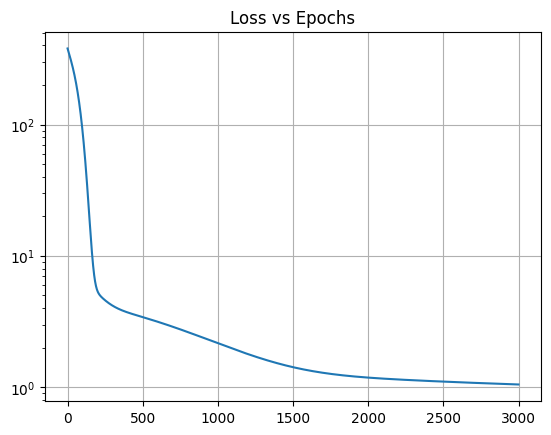

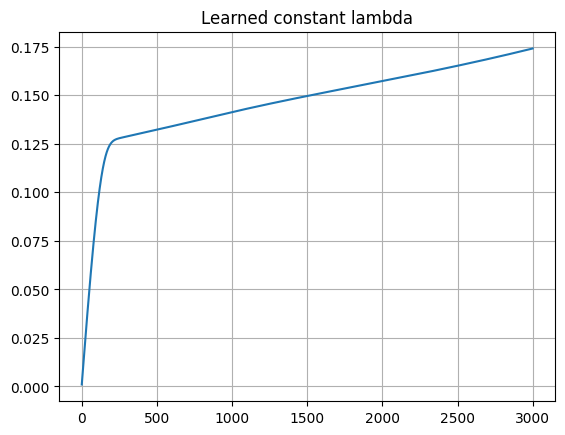

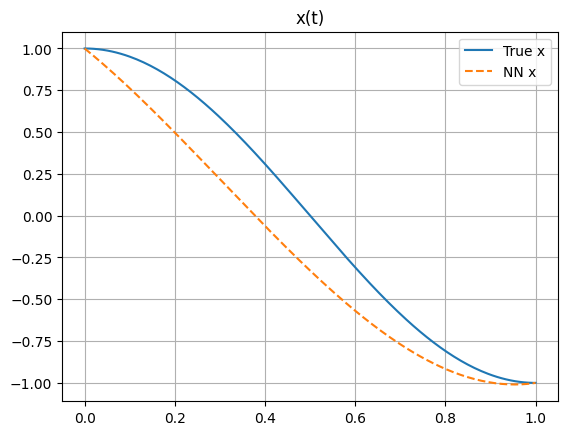

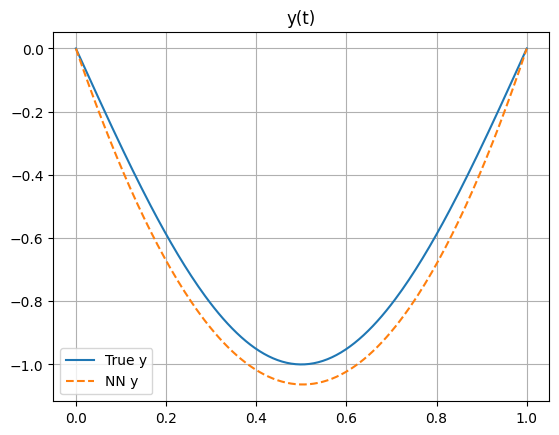

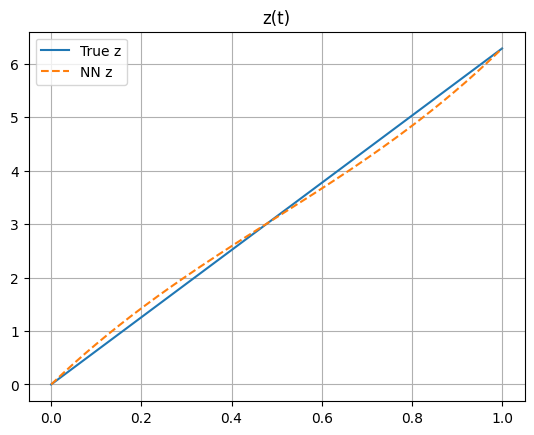

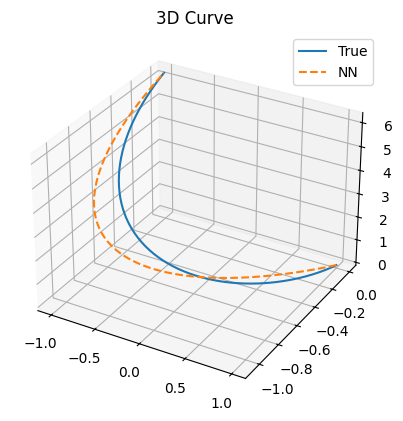

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Model (curve only)
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='tanh'),

        tf.keras.layers.Dense(3)  # nn1, nn2, nn3
    ])

model = build_model()
optimizer = tf.keras.optimizers.Adam(1e-3)

# Trainable scalar lambda
lam = tf.Variable(0.0, dtype=tf.float32, trainable=True)

# -----------------------------
# Grid
# -----------------------------
N = 200
t_np = np.linspace(0.0, 1.0, N).reshape(-1,1).astype(np.float32)
t = tf.convert_to_tensor(t_np)

# -----------------------------
# Forward (hard embedding)
# -----------------------------
def forward(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)

        nn = model(t)
        nn1 = nn[:,0:1]
        nn2 = nn[:,1:2]
        nn3 = nn[:,2:3]

        x = 1 - 2*t + t*(1-t)*nn1
        y = t*(1-t)*nn2
        z = 2*np.pi*t + t*(1-t)*nn3

    dx = tape.gradient(x, t)
    dy = tape.gradient(y, t)
    dz = tape.gradient(z, t)

    return x, y, z, dx, dy, dz

# -----------------------------
# Loss
# -----------------------------
def loss_fn():
    x, y, z, dx, dy, dz = forward(t)

    r = tf.sqrt(x**2 + y**2 + 1e-6)

    constraint = dz + 2*x*dy - 2*y*dx

    integrand = 1.0/r - lam * constraint

    action = tf.reduce_mean(integrand)

    # stabilization (important)
    constraint_reg = tf.reduce_mean(constraint**2)

    loss = action + 10.0 * constraint_reg

    return loss, action, constraint_reg

# -----------------------------
# Training
# -----------------------------
epochs = 3000
loss_hist = []
lam_hist = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        loss, act, cons = loss_fn()

    vars_all = model.trainable_variables + [lam]
    grads = tape.gradient(loss, vars_all)
    optimizer.apply_gradients(zip(grads, vars_all))

    loss_hist.append(float(loss.numpy()))
    lam_hist.append(float(lam.numpy()))

    if ep % 200 == 0:
        print(f"Epoch {ep}: Loss={float(loss.numpy()):.5f}, "
              f"Action={float(act.numpy()):.5f}, "
              f"Constraint={float(cons.numpy()):.5f}, "
              f"Lambda={float(lam.numpy()):.5f}")

# -----------------------------
# Extract solution
# -----------------------------
x_pred, y_pred, z_pred, _, _, _ = forward(t)

x_pred = x_pred.numpy().flatten()
y_pred = y_pred.numpy().flatten()
z_pred = z_pred.numpy().flatten()

# -----------------------------
# True solution
# -----------------------------
t_true = t_np.flatten()

x_true = np.cos(np.pi*t_true)
y_true = -np.sin(np.pi*t_true)
z_true = 2*np.pi*t_true

# -----------------------------
# Plots
# -----------------------------

# Loss
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Loss vs Epochs")
plt.grid()
plt.show()

# Lambda evolution
plt.figure()
plt.plot(lam_hist)
plt.title("Learned constant lambda")
plt.grid()
plt.show()

# x
plt.figure()
plt.plot(t_true, x_true, label="True x")
plt.plot(t_true, x_pred, '--', label="NN x")
plt.legend(); plt.title("x(t)"); plt.grid(); plt.show()

# y
plt.figure()
plt.plot(t_true, y_true, label="True y")
plt.plot(t_true, y_pred, '--', label="NN y")
plt.legend(); plt.title("y(t)"); plt.grid(); plt.show()

# z
plt.figure()
plt.plot(t_true, z_true, label="True z")
plt.plot(t_true, z_pred, '--', label="NN z")
plt.legend(); plt.title("z(t)"); plt.grid(); plt.show()

# 3D curve
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_true, y_true, z_true, label="True")
ax.plot(x_pred, y_pred, z_pred, '--', label="NN")

ax.legend()
ax.set_title("3D Curve")
plt.show()

**Penalty formulation with weight learning**

Instead of introducing a Lagrange multiplier, the constraint can be enforced using a penalty term in the loss functional, subject to be learned by the network. The resulting loss is
$$
L(\theta)=
\int_0^1
\left(
\frac{1}{\sqrt{x_\theta^2+y_\theta^2}}
+
\alpha
\big(\dot z_\theta + 2x_\theta\dot y_\theta - 2y_\theta\dot x_\theta\big)^2
\right)\,dt ,
$$
where $\alpha>0$ is a penalty weight controlling how strongly the constraint is enforced. In this version $\alpha$ is learned by the network.


Epoch 0: Loss=14276.20215, Action=4.31165, Constraint=1427.18909, Lambda=0.00030
Epoch 200: Loss=5198.88525, Action=0.77450, Constraint=519.81110, Lambda=0.05451
Epoch 400: Loss=1134.60120, Action=0.51036, Constraint=113.40909, Lambda=0.09075
Epoch 600: Loss=276.99298, Action=0.70499, Constraint=27.62880, Lambda=0.11165
Epoch 800: Loss=91.41136, Action=0.82795, Constraint=9.05834, Lambda=0.12457
Epoch 1000: Loss=38.81580, Action=0.88858, Constraint=3.79272, Lambda=0.13356
Epoch 1200: Loss=20.79443, Action=0.91940, Constraint=1.98750, Lambda=0.14053
Epoch 1400: Loss=13.49508, Action=0.93716, Constraint=1.25579, Lambda=0.14636
Epoch 1600: Loss=9.89166, Action=0.94811, Constraint=0.89435, Lambda=0.15148
Epoch 1800: Loss=7.77881, Action=0.95479, Constraint=0.68240, Lambda=0.15616
Epoch 2000: Loss=6.37901, Action=0.95850, Constraint=0.54205, Lambda=0.16055
Epoch 2200: Loss=5.37535, Action=0.95999, Constraint=0.44154, Lambda=0.16477
Epoch 2400: Loss=4.62339, Action=0.95969, Constraint=0.3663

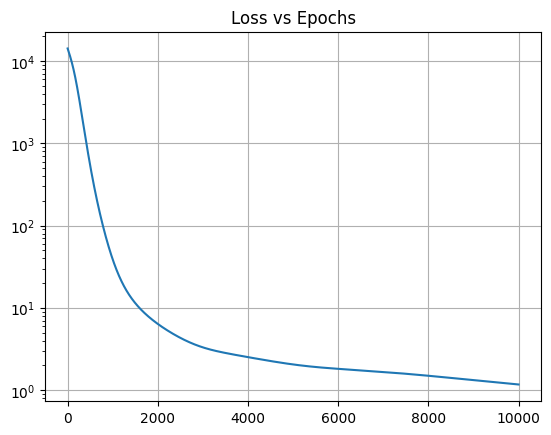

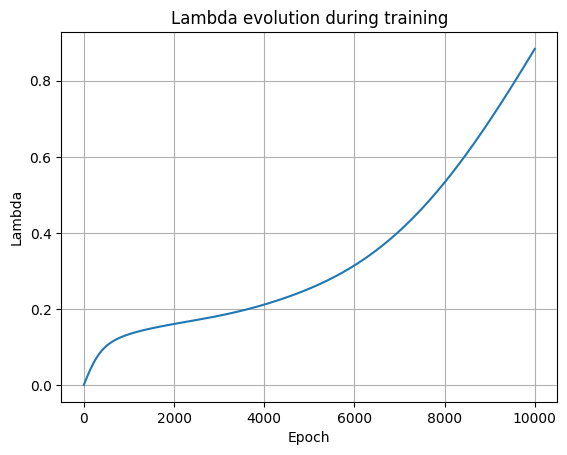

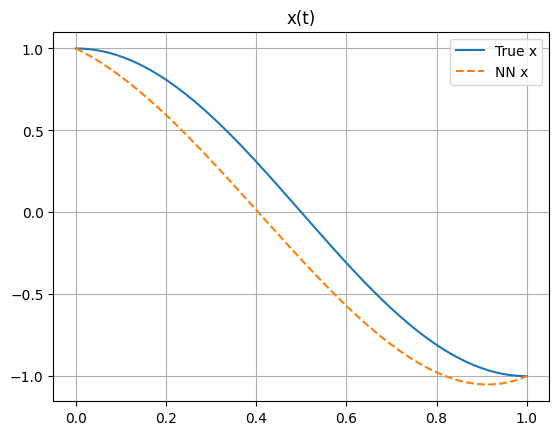

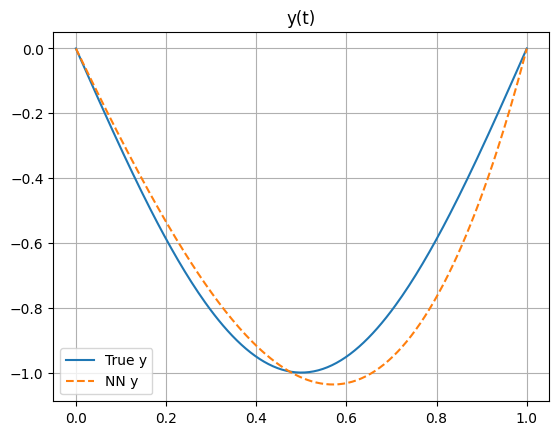

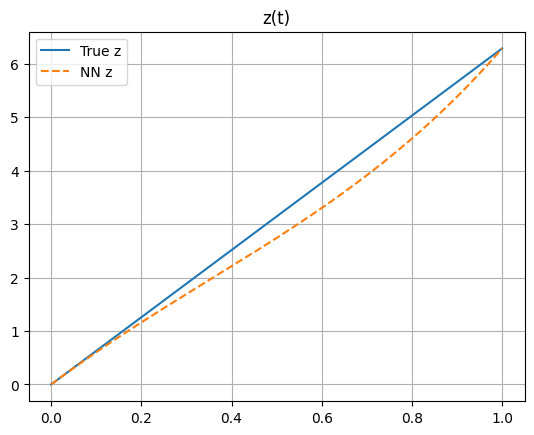

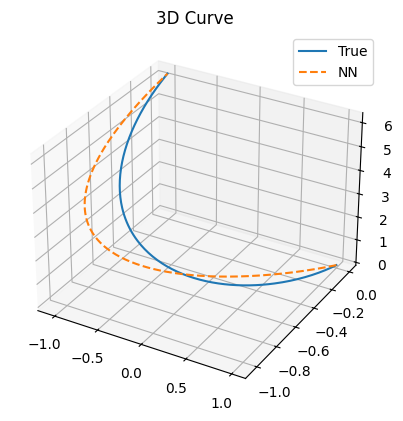

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Model
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='swish'),##########
        tf.keras.layers.Dense(3)
    ])

model = build_model()
optimizer = tf.keras.optimizers.Adam(3e-4)

# Trainable scalar lambda
lam = tf.Variable(0.0, dtype=tf.float32, trainable=True)

# -----------------------------
# Grid
# -----------------------------
N = 200
t_np = np.linspace(0.0, 1.0, N).reshape(-1,1).astype(np.float32)
t = tf.convert_to_tensor(t_np)

# -----------------------------
# Forward
# -----------------------------
def forward(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)

        nn = model(t)
        nn1 = nn[:,0:1]
        nn2 = nn[:,1:2]
        nn3 = nn[:,2:3]

        x = 1 - 2*t + t*(1-t)*nn1
        y = t*(1-t)*nn2
        z = 2*np.pi*t + t*(1-t)*nn3

    dx = tape.gradient(x, t)
    dy = tape.gradient(y, t)
    dz = tape.gradient(z, t)

    return x, y, z, dx, dy, dz

# -----------------------------
# Loss
# -----------------------------
def loss_fn():
    x, y, z, dx, dy, dz = forward(t)

    r = tf.sqrt(x**2 + y**2 + 1e-6)
    constraint = (dz + 2*x*dy - 2*y*dx)**2 ###########

    integrand = 1.0/r - lam * constraint
    action = tf.reduce_mean(integrand)

    # stabilization
    constraint_reg = tf.reduce_mean(constraint**2)

    loss = action + 10.0 * constraint_reg

    return loss, action, constraint_reg

# -----------------------------
# Training
# -----------------------------
epochs = 10000
loss_hist = []
lam_hist = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        loss, act, cons = loss_fn()

    vars_all = model.trainable_variables + [lam]
    grads = tape.gradient(loss, vars_all)
    optimizer.apply_gradients(zip(grads, vars_all))

    loss_hist.append(float(loss.numpy()))
    lam_hist.append(float(lam.numpy()))

    if ep % 200 == 0:
        print(f"Epoch {ep}: Loss={float(loss.numpy()):.5f}, "
              f"Action={float(act.numpy()):.5f}, "
              f"Constraint={float(cons.numpy()):.5f}, "
              f"Lambda={float(lam.numpy()):.5f}")

# -----------------------------
# Extract solution
# -----------------------------
x_pred, y_pred, z_pred, _, _, _ = forward(t)

x_pred = x_pred.numpy().flatten()
y_pred = y_pred.numpy().flatten()
z_pred = z_pred.numpy().flatten()

# -----------------------------
# True solution
# -----------------------------
t_true = t_np.flatten()

x_true = np.cos(np.pi*t_true)
y_true = -np.sin(np.pi*t_true)
z_true = 2*np.pi*t_true

# -----------------------------
# Plots
# -----------------------------

# Loss
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Loss vs Epochs")
plt.grid()
plt.show()

# ✅ Lambda vs epochs (NEW, clean)
plt.figure()
plt.plot(lam_hist)
plt.title("Lambda evolution during training")
plt.xlabel("Epoch")
plt.ylabel("Lambda")
plt.grid()
plt.show()

# x(t)
plt.figure()
plt.plot(t_true, x_true, label="True x")
plt.plot(t_true, x_pred, '--', label="NN x")
plt.legend()
plt.title("x(t)")
plt.grid()
plt.show()

# y(t)
plt.figure()
plt.plot(t_true, y_true, label="True y")
plt.plot(t_true, y_pred, '--', label="NN y")
plt.legend()
plt.title("y(t)")
plt.grid()
plt.show()

# z(t)
plt.figure()
plt.plot(t_true, z_true, label="True z")
plt.plot(t_true, z_pred, '--', label="NN z")
plt.legend()
plt.title("z(t)")
plt.grid()
plt.show()

# 3D trajectory
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_true, y_true, z_true, label="True")
ax.plot(x_pred, y_pred, z_pred, '--', label="NN")

ax.legend()
ax.set_title("3D Curve")
plt.show()